In [2]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
def generate_time_series(batch_size, n_step):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_step)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  # Wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))  # Wave 2
    series += 0.1 * (np.random.rand(batch_size, n_step) - 0.5)  # Noise
    return series[..., np.newaxis].astype(np.float32)

In [4]:
nstep = 50
series = generate_time_series(10000, nstep + 1)
X_train, y_train = series[:7000, :nstep], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :nstep], series[7000:9000, -1]
X_test, y_test = series[9000:, :nstep], series[9000:, -1]

In [5]:
Ypred = X_valid[:,-1]
np.mean(keras.losses.mse(y_valid, Ypred).numpy())

np.float32(0.020857913)

In [6]:
epochs = 10
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[nstep, 1]),
    keras.layers.Dense(1)
])
model.summary()

c:\Program Files\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3553 - val_loss: 0.1352
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0965 - val_loss: 0.0740
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0584 - val_loss: 0.0485
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0391 - val_loss: 0.0337
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0275 - val_loss: 0.0245
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0204 - val_loss: 0.0187
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0162 - val_loss: 0.0154
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0132
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - val_loss: 0.0116
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0105 - val_loss: 0.0105


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


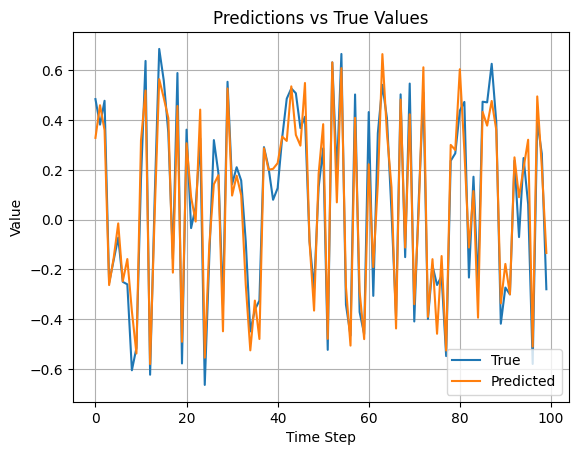

np.float32(0.010503725)

In [8]:
y_pred = model.predict(X_valid)
# Handle single-step and multi-step predictions robustly
if hasattr(y_pred, 'ndim') and y_pred.ndim == 2 and y_pred.shape[1] > 1:
    plt.plot(y_valid[:100, 0], label='True (step 0)')
    plt.plot(y_pred[:100, 0], label='Predicted (step 0)')
else:
    plt.plot(np.squeeze(y_valid[:100]), label='True')
    plt.plot(np.squeeze(y_pred[:100]), label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mse(y_valid, y_pred).numpy())

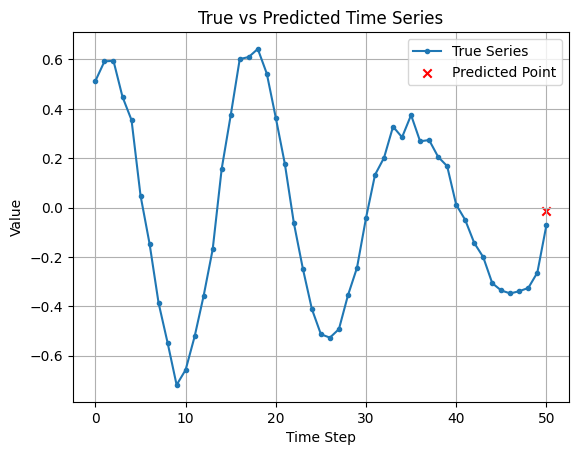

In [9]:
plt.plot(np.hstack((X_valid[5,:,0],y_valid[5])),marker = '.', label='True Series')
plt.scatter([nstep], y_pred[5], marker = 'x',color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

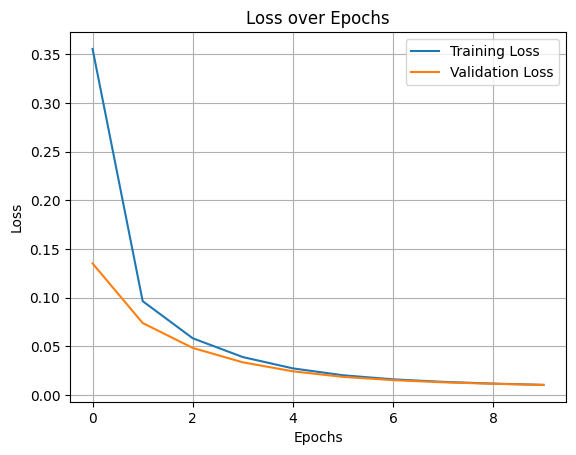

In [10]:
def plot_results(history):
       
    # Plot loss
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_results(history)

## RNN

In [11]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1]),
])
model.summary()

c:\Program Files\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1158 - val_loss: 0.0336
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0163 - val_loss: 0.0114
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0115 - val_loss: 0.0112
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0114 - val_loss: 0.0111
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0113 - val_loss: 0.0111
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0113 - val_loss: 0.0110


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


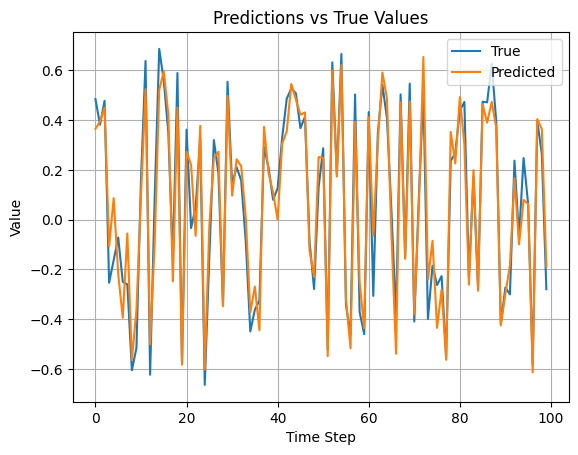

np.float32(0.011010322)

In [13]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mse(y_valid, y_pred).numpy())

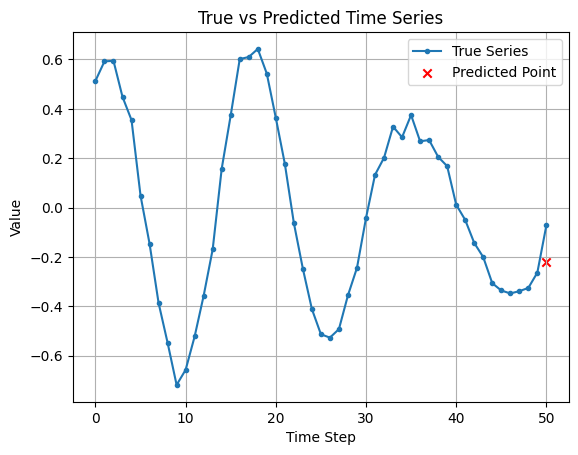

In [14]:
plt.plot(np.hstack((X_valid[5,:,0],y_valid[5])),marker = '.', label='True Series')
plt.scatter([nstep], y_pred[5], marker = 'x',color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

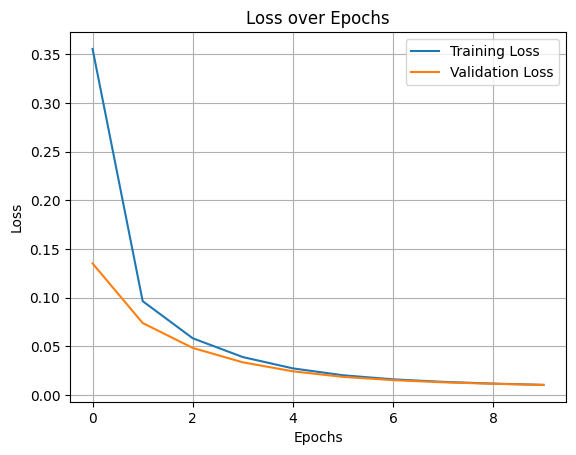

In [15]:
plot_results(history)

In [16]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0137 - val_loss: 0.0039
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0042 - val_loss: 0.0036
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0037 - val_loss: 0.0043
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0035 - val_loss: 0.0041
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0034 - val_loss: 0.0037
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0034 - val_loss: 0.0043


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


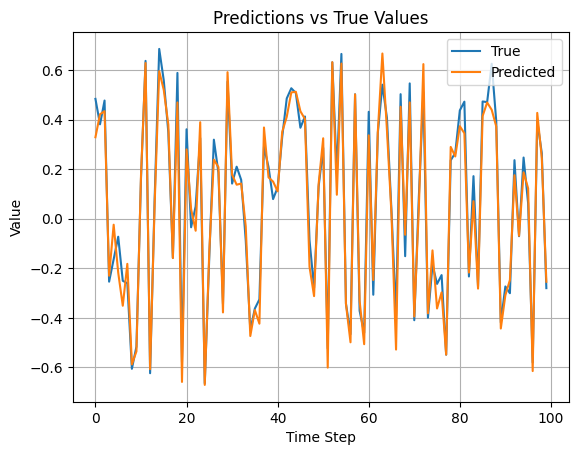

np.float32(0.004269771)

In [18]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mse(y_valid, y_pred).numpy())


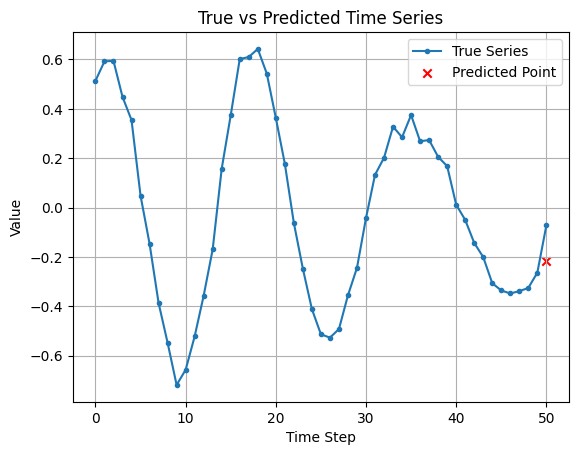

In [19]:
plt.plot(np.hstack((X_valid[5,:,0],y_valid[5])),marker = '.', label='True Series')
plt.scatter([nstep], y_pred[5], marker = 'x',color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

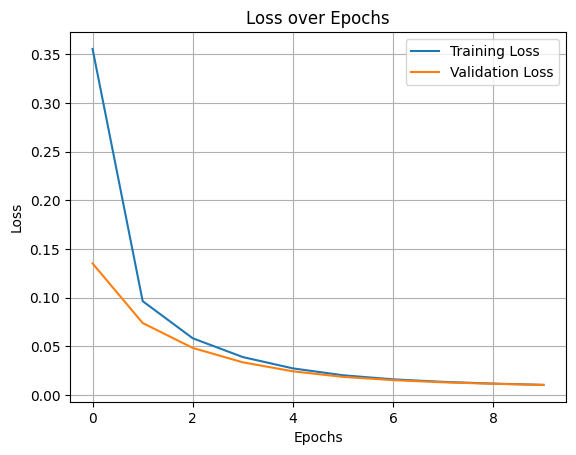

In [20]:
plot_results(history)

In [21]:
series = generate_time_series(10000, nstep + 10)
X_train, y_train = series[:7000, :nstep], series[:7000, -10:, 0]
X_valid, y_valid = series[7000:9000, :nstep], series[7000:9000, -10:, 0]
X_test, y_test = series[9000:, :nstep], series[9000:, -10:, 0]

In [22]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0444 - val_loss: 0.0446
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0274 - val_loss: 0.0214
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0239 - val_loss: 0.0211
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0262 - val_loss: 0.0278
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0226 - val_loss: 0.0244
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0225 - val_loss: 0.0176
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0163 - val_loss: 0.0128
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0148 - val_loss: 0.0142
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0144 - val_loss: 0.0114
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0115 - val_loss: 0.0094


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


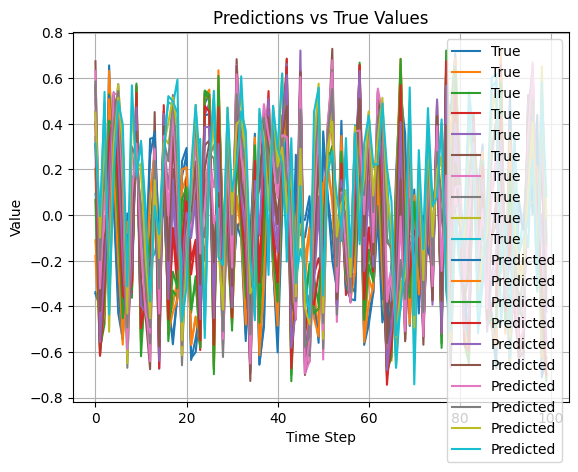

np.float32(0.009397274)

In [24]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mse(y_valid, y_pred).numpy())


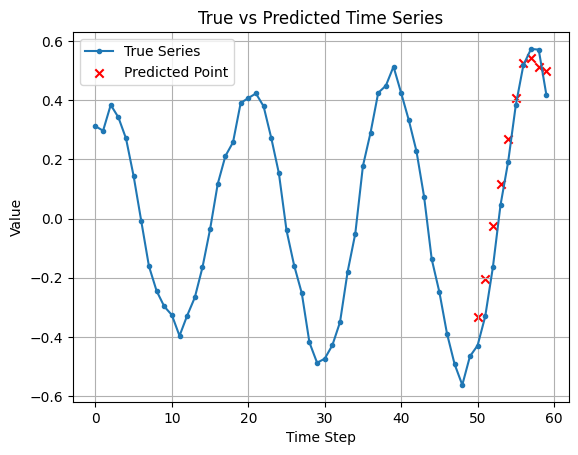

In [25]:
plt.plot(np.hstack((X_valid[5,:,0], y_valid[5])), marker='.', label='True Series')
plt.scatter(np.arange(nstep, nstep + 10), y_pred[5, :], marker='x', color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

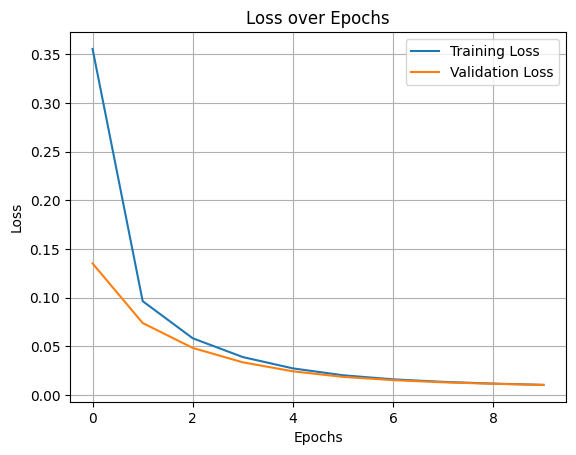

In [26]:
plot_results(history)

In [27]:
Y = np.empty((10000,nstep,10))
for i in range(1,10+1):
    Y[:,:,i-1] = series[:,i:i+nstep,0]
y_train, y_valid, y_test = Y[:7000], Y[7000:9000], Y[9000:]

In [28]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(1, 1)),
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 1, 20)          │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 1, 20)          │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 10)          │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
def last_time_step_mse(y_true, y_pred):
    return keras.losses.mse(y_true[:, -1], y_pred[:, -1])
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2),
              metrics = [last_time_step_mse])
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - last_time_step_mse: 0.0331 - loss: 0.0460 - val_last_time_step_mse: 0.0235 - val_loss: 0.0367
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - last_time_step_mse: 0.0207 - loss: 0.0342 - val_last_time_step_mse: 0.0229 - val_loss: 0.0341
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0179 - loss: 0.0309 - val_last_time_step_mse: 0.0173 - val_loss: 0.0289
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0152 - loss: 0.0276 - val_last_time_step_mse: 0.0134 - val_loss: 0.0257
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0129 - loss: 0.0253 - val_last_time_step_mse: 0.0127 - val_loss: 0.0240
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - last_time_step_mse: 0.0096 - loss: 0.0224 - val_last_time_step_mse: 0.0077 - val_loss: 0.0208
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - last_time_step_mse: 0.0084 - loss: 0.0212 - val_la

In [30]:
y_pred = model.predict(X_valid)
np.mean(keras.losses.mse(y_valid, y_pred).numpy())
print(np.mean(keras.losses.mse(y_valid, y_pred).numpy()))
print(np.mean(last_time_step_mse(y_valid, y_pred).numpy()))
print(y_pred[:,-1].shape)
print(y_pred[:,-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
0.019525856
0.007520628
(2000, 10)
[[-0.43219414 -0.21275078  0.04376147 ...  0.51705116  0.38669974
   0.25445503]
 [-0.40395558 -0.5322654  -0.61517787 ... -0.22102699 -0.08031241
   0.0288512 ]
 [-0.2942107  -0.32235527 -0.31887951 ...  0.4030185   0.5359578
   0.60005033]
 ...
 [ 0.3739614   0.2596372   0.09244473 ... -0.5842476  -0.5815894
  -0.5253268 ]
 [ 0.39315644  0.5323828   0.6436693  ...  0.19728638 -0.0446322
  -0.26701298]
 [-0.16219164 -0.24937826 -0.32883075 ... -0.35263896 -0.30727366
  -0.25889617]]


In [31]:
# LSTM
model = keras.models.Sequential([
    keras.layers.Input(shape=(1,1)),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 20)          │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 20)          │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 1, 10)          │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2),
                metrics = [last_time_step_mse])

In [33]:
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - last_time_step_mse: 0.0342 - loss: 0.0479 - val_last_time_step_mse: 0.0171 - val_loss: 0.0322
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - last_time_step_mse: 0.0131 - loss: 0.0285 - val_last_time_step_mse: 0.0117 - val_loss: 0.0264
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - last_time_step_mse: 0.0082 - loss: 0.0237 - val_last_time_step_mse: 0.0080 - val_loss: 0.0223
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - last_time_step_mse: 0.0060 - loss: 0.0208 - val_last_time_step_mse: 0.0056 - val_loss: 0.0195
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - last_time_step_mse: 0.0052 - loss: 0.0190 - val_last_time_step_mse: 0.0059 - val_loss: 0.0188
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - last_time_step_mse: 0.0046 - loss: 0.0179 - val_last_time_step_mse: 0.0050 - val_loss: 0.0176
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - last_time_step_mse: 0.0043 - loss: 0.0170 - val_la

In [34]:
y_pred = model.predict(X_valid)
np.mean(keras.losses.mse(y_valid, y_pred).numpy())

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


np.float32(0.015118946)

In [35]:
model=keras.models.Sequential([
    keras.layers.Conv1D(filters=20, kernel_size=4, strides=2,padding = 'valid', input_shape=[None, 1]),
    keras.layers.GRU(20,return_sequences=True),
    keras.layers.GRU(20,return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.summary()

c:\Program Files\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, None, 20)       │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,350 (20.90 KB)

 Trainable params: 5,350 (20.90 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(loss=keras.losses.mse, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2),
                metrics = [last_time_step_mse])
model.fit(X_train, y_train[:,3::2], epochs=epochs,validation_data=(X_valid, y_valid[:,3::2]))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - last_time_step_mse: 0.0321 - loss: 0.0401 - val_last_time_step_mse: 0.0158 - val_loss: 0.0255
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - last_time_step_mse: 0.0116 - loss: 0.0219 - val_last_time_step_mse: 0.0082 - val_loss: 0.0184
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - last_time_step_mse: 0.0063 - loss: 0.0163 - val_last_time_step_mse: 0.0070 - val_loss: 0.0166
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - last_time_step_mse: 0.0051 - loss: 0.0145 - val_last_time_step_mse: 0.0047 - val_loss: 0.0139
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - last_time_step_mse: 0.0044 - loss: 0.0134 - val_last_time_step_mse: 0.0054 - val_loss: 0.0136
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - last_time_step_mse: 0.0044 - loss: 0.0129 - val_last_time_step_mse: 0.0043 - val_loss: 0.0126
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - last_time_step_mse: 0.0041 - loss: 0.0124 - val_la

In [37]:
y_pred = model.predict(X_valid)
np.mean(keras.losses.mse(y_valid[:,3::2], y_pred).numpy())
print(np.mean(keras.losses.mse(y_valid[:,3::2], y_pred).numpy()))
print(np.mean(last_time_step_mse(y_valid[:,3::2], y_pred).numpy()))
print(y_pred[:,-1].shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
0.01129363
0.003543674
(2000, 10)
